# Calcule des statistiques de segmentation

## 1. Importation des librairies

- `os` pour interagir avec le système de fichiers.
- `csv` pour sauvegarder les résultats au format CSV.
- `numpy` pour la manipulation des tableaux (les images sont des tableaux de pixels).
- `matplotlib.pyplot` pour afficher l'histogramme de distribution des scores IoU.
- `PIL (Pillow)` pour manipuler les images.
- `tqdm` pour afficher une barre de progression (utile pour plusieurs images).
- `concurrent.futures` pour traiter les images de manière concurante.

In [17]:
import os
import csv

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

### Variables de configuration

- `MASK_DIR`: Le chemin vers le dossier contenant les masques de référence (Ground Truth).
- `RESULTS_DIR`: Le chemin vers le dossier contenant les masques prédits par l'IA.
- `MAX_IMAGES`: Le nombre maximum de paires masque/résultat à évaluer.
- `MAX_WORKERS`: Le nombre maximum de workers en simultané pour calculer l'IoU.
- `STATS_OUTPUT_PATH`: Chemin vers le fichier CSV de sortie des statistiques IoU.

In [18]:
# Déffinir les constantes
MASK_DIR = "../data/Mask"
RESULTS_DIR = "../data/Results"
MAX_IMAGES = 50
MAX_WORKERS = 5
STATS_OUTPUT_PATH = "../data/iou_statistics.csv"

# S'assurer que le dossier des masques de référence existe
if not os.path.isdir(MASK_DIR):
    raise FileNotFoundError(f"Erreur: Le dossier des masques à {MASK_DIR} n'a pas été trouvé.")

# S'assurer que le dossier des résultats existe
if not os.path.isdir(RESULTS_DIR):
    raise FileNotFoundError(f"Erreur: Le dossier des résultats à {RESULTS_DIR} n'a pas été trouvé.")

# S'assurer que le dossier de sortie du CSV existe
stats_output_dir = os.path.dirname(STATS_OUTPUT_PATH)
if stats_output_dir and not os.path.isdir(stats_output_dir):
    os.makedirs(stats_output_dir)

## 2. Récupérer les chemins des masques et des résultats

- `get_image_paths`: Récupérer les chemins vers les images d'un dossier.

In [19]:
def get_image_paths(dir_path: str, max_images: int | None = MAX_IMAGES) -> list[str]:
    """
    Get all image paths at the root of a directory

    Args:
        dir_path (str): Path to the folder.
        max_images (int | None): Max images count.

    Returns:
        the list of all image paths of the specified folder
    """

    # Extensions possibles pour des images.
    image_extensions = (".jpg", ".jpeg", ".png", ".webp")
    # Lister tout les elements du dossier spécifié dans les paramètres de la fonction.
    directory_elements = sorted(os.listdir(dir_path))
    # Recréer les chemins complets avec dir_path + el
    directory_elements = map(lambda el: os.path.join(dir_path, el), directory_elements)
    # Créer un nouveau tableau en ne gardant que les éléments qui sont des fichiers.
    directory_files = [f for f in directory_elements if os.path.isfile(f)]
    # Filtrer les images (c'est une image si son extension est comprise dans image_extensions).
    directory_images = list(filter(lambda p: os.path.splitext(p)[1].lower() in image_extensions, directory_files))
    # S'assurer de ne pas dépasser le nombre max d'images à traiter
    if max_images:
        directory_images = directory_images[:max_images]

    if not directory_images:
        print(f"Aucunes image trouvée dans '{dir_path}', Veuillez y ajouter des images")
    else:
        print(f"{len(directory_images)} image(s) à traiter.")

    return directory_images


def get_result_path_for_mask(mask_path: str, results_dir: str = RESULTS_DIR) -> str:
    """
    Associe un masque de référence (mask_N.png) au masque prédit correspondant (image_N.png).

    Args:
        mask_path (str): Chemin vers le masque de référence.
        results_dir (str): Dossier contenant les masques prédits.

    Returns:
        Chemin vers le masque prédit associé.
    """

    base_name = os.path.splitext(os.path.basename(mask_path))[0]
    if not base_name.startswith("mask_"):
        raise ValueError(f"Le fichier {mask_path} ne suit pas le format attendu 'mask_N.png'.")

    image_id = base_name.removeprefix("mask_")
    return os.path.join(results_dir, f"image_{image_id}.png")

## 3. Calcule du IoU

- `calculate_iou`: Calcule l'IoU entre les masques de testes et les resultats.

In [20]:
def calculate_iou(result_mask_path: str, test_mask_path: str):
    """
    Calcule l'Intersection over Union (IoU) entre deux masques de segmentation.
    
    Args:
        result_mask_path: Chemin vers le masque prédit par l'IA.
        test_mask_path: Chemin vers le masque réel (Ground Truth).
        
    Returns:
        Score IoU compris entre 0.0 et 1.0.
    """

    # Charger l'image et son masque en niveaux de gris (via `convert("L")`)
    result_img = Image.open(result_mask_path).convert("L")
    test_img = Image.open(test_mask_path).convert("L")

    # S'assurer que les deux images aient la même taille
    if result_img.size != test_img.size:
        result_img = result_img.resize(test_img.size, resample=Image.NEAREST)

    # Convertir les deux images en tableaux Numpy
    # `> 0` permet de ne pas mettre le fond (qui est à 0)
    mask_pred = np.array(result_img) > 0
    mask_true = np.array(test_img) > 0

    intersection = np.logical_and(mask_pred, mask_true).sum()
    union = np.logical_or(mask_pred, mask_true).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    # Calculer le score final
    iou_score = intersection / union

    return float(iou_score)

## 4. Calcul de l'IoU pour plusieurs images

- `calculate_iou_for_mask`: Calcule l'IoU pour une paire masque/résultat à partir du chemin du masque de référence.
- `calculate_iou_batch`: Calcule l'IoU pour plusieurs images en parallèle et retourne une liste de scores.

In [21]:
def calculate_iou_for_mask(mask_path: str) -> float:
    """
    Calcule l'IoU pour un masque de référence et son résultat associé.

    Args:
        mask_path (str): Chemin vers le masque de référence (Ground Truth).

    Returns:
        Score IoU compris entre 0.0 et 1.0.
    """

    result_path = get_result_path_for_mask(mask_path)

    if not os.path.isfile(result_path):
        raise FileNotFoundError(f"Résultat introuvable pour {mask_path}: {result_path}")

    return calculate_iou(result_path, mask_path)


def calculate_iou_batch(list_of_mask_paths: list[str]) -> list[float]:
    """
    Calcule l'IoU pour une liste de masques de référence en parallèle.

    Args:
        list_of_mask_paths (list[str]): Liste des chemins vers les masques de référence.

    Returns:
        list[float]: Liste des scores IoU, dans le même ordre que list_of_mask_paths.
        Contient 0.0 pour toute image qui n'a pas pu être traitée.
    """

    batch_ious: list[float] = [0.0] * len(list_of_mask_paths)

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futute_to_index = {
            executor.submit(calculate_iou_for_mask, path): i for i, path in enumerate(list_of_mask_paths)
        }

        for future in tqdm(
            as_completed(futute_to_index),
            total=len(list_of_mask_paths),
            desc="Calcul IoU en cours"
        ):
            index = futute_to_index[future]
            try:
                batch_ious[index] = future.result()
            except:
                batch_ious[index] = 0.0

    return batch_ious

## 5. Sauvegarder les resultats dans un fichier CSV

- `save_results` Sauvegarder les fichiers au format CSV avec les champs: index, tested_mask, test_mask, iou_score. Plus un champ moyenne à la fin de tout les scores. 

In [22]:
def save_results(
    mask_paths: list[str],
    iou_scores: list[float],
    output_path: str = STATS_OUTPUT_PATH,
) -> None:
    """
    Sauvegarde les scores IoU dans un fichier CSV.

    Args:
        mask_paths (list[str]): Liste des chemins vers les masques de référence.
        iou_scores (list[float]): Liste des scores IoU associés.
        output_path (str): Chemin du fichier CSV de sortie.
    """

    if len(mask_paths) != len(iou_scores):
        raise ValueError("mask_paths et iou_scores doivent avoir la même longueur.")

    fieldnames = ["index", "tested_mask", "test_mask", "iou_score"]

    with open(output_path, "w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        writer.writeheader()

        for index, (mask_path, iou_score) in enumerate(zip(mask_paths, iou_scores)):
            result_path = get_result_path_for_mask(mask_path)
            writer.writerow({
                "index": index,
                "tested_mask": os.path.basename(result_path),
                "test_mask": os.path.basename(mask_path),
                "iou_score": iou_score,
            })

        mean_iou = float(np.mean(iou_scores)) if iou_scores else 0.0
        writer.writerow({
            "index": "average",
            "tested_mask": "",
            "test_mask": "",
            "iou_score": mean_iou,
        })

    print(f"Résultats sauvegardés dans {output_path}")

## 6. Affichage des resultats

- `display_iou_distribution`: Affiche un histogramme de la distribution des scores IoU.

In [23]:
def display_iou_distribution(iou_scores: list[float], bins: int = 20) -> None:
    """
    Affiche un histogramme de la distribution des scores IoU.

    Args:
        iou_scores (list[float]): Liste des scores IoU (entre 0.0 et 1.0).
        bins (int): Nombre de barres de l'histogramme.
    """

    if not iou_scores:
        print("Aucun score IoU à afficher.")
        return

    mean_iou = float(np.mean(iou_scores))

    _, ax = plt.subplots(figsize=(10, 6))
    ax.hist(iou_scores, bins=bins, range=(0, 1), edgecolor="black", alpha=0.7)
    ax.axvline(
        mean_iou,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Moyenne : {mean_iou:.3f}",
    )
    ax.set_xlabel("Score IoU")
    ax.set_ylabel("Nombre d'images")
    ax.set_title("Distribution des scores IoU")
    ax.set_xlim(0, 1)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Lancer le script

50 image(s) à traiter.
Calcul de l'IoU en batch...


Calcul IoU en cours: 100%|██████████| 50/50 [00:00<00:00, 767.07it/s]

Calcul terminé.


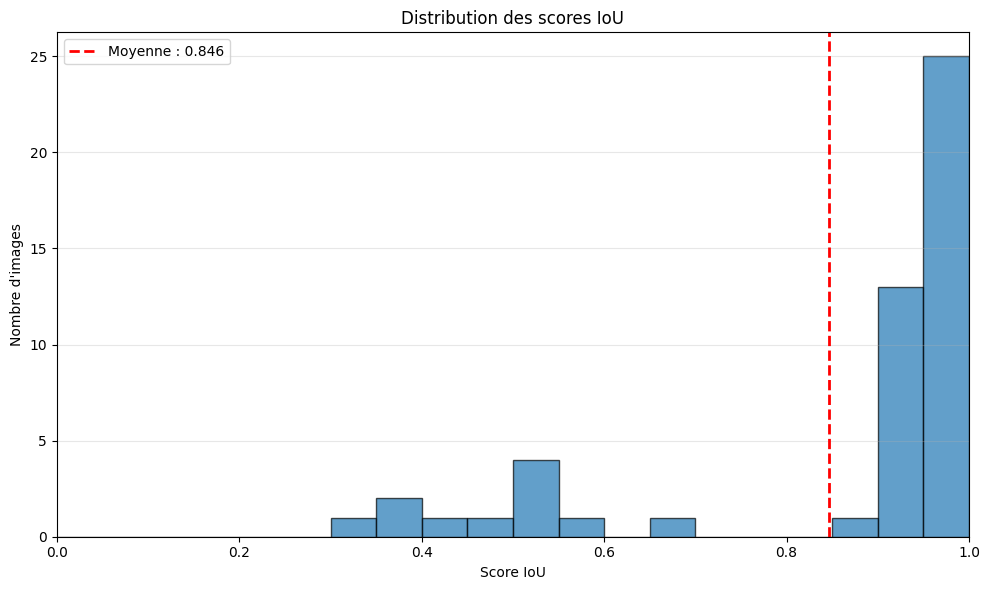

Résultats sauvegardés dans ../data/iou_statistics.csv


In [24]:
if __name__ == "__main__": # Pour s'assurer que c'est bien le fichier depuis lequel on a lancé le code
    mask_paths = get_image_paths(MASK_DIR)

    # Si il n'y a pas de masques, quitter le programme.
    # 'get_image_paths' s'occupe déja d'afficher un message dans ce cas.
    if not mask_paths:
        raise SystemExit("Impossible de calculer l'IoU sans masques de référence.")

    print("Calcul de l'IoU en batch...")
    iou_scores = calculate_iou_batch(mask_paths)
    print("Calcul terminé.")

    display_iou_distribution(iou_scores)

    save_results(mask_paths, iou_scores)